## Importing Datasets

In [1]:
import kagglehub

path = kagglehub.dataset_download("openfoodfacts/world-food-facts")

print("Path to dataset files:", path)

Path to dataset files: /Users/yarayaghi/.cache/kagglehub/datasets/openfoodfacts/world-food-facts/versions/5


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

## Data Exploration

In [3]:
import kagglehub, os, pandas as pd
print(os.listdir(path))

tsv_path = [f for f in os.listdir(path) if f.endswith(".tsv")][0]
print("Found file:", tsv_path)

file_path = f"{path}/{tsv_path}"
df = pd.read_csv(
    "en.openfoodfacts.org.products.tsv",
    sep='\t',
    low_memory=False,
    on_bad_lines='warn'
)
print(df.columns.tolist())

['en.openfoodfacts.org.products.tsv']
Found file: en.openfoodfacts.org.products.tsv
['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'product_name', 'generic_name', 'quantity', 'packaging', 'packaging_tags', 'brands', 'brands_tags', 'categories', 'categories_tags', 'categories_en', 'origins', 'origins_tags', 'manufacturing_places', 'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_en', 'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores', 'countries', 'countries_tags', 'countries_en', 'ingredients_text', 'allergens', 'allergens_en', 'traces', 'traces_tags', 'traces_en', 'serving_size', 'no_nutriments', 'additives_n', 'additives', 'additives_tags', 'additives_en', 'ingredients_from_palm_oil_n', 'ingredients_from_palm_oil', 'ingredients_from_palm_oil_tags', 'ingredients_that_may_be_from_palm_oil_n', 'ingredients_that_may_be_from_palm_oil', 'ingredients_that_may_b

In [4]:
for col in df.columns:
    print(col)

code
url
creator
created_t
created_datetime
last_modified_t
last_modified_datetime
product_name
generic_name
quantity
packaging
packaging_tags
brands
brands_tags
categories
categories_tags
categories_en
origins
origins_tags
manufacturing_places
manufacturing_places_tags
labels
labels_tags
labels_en
emb_codes
emb_codes_tags
first_packaging_code_geo
cities
cities_tags
purchase_places
stores
countries
countries_tags
countries_en
ingredients_text
allergens
allergens_en
traces
traces_tags
traces_en
serving_size
no_nutriments
additives_n
additives
additives_tags
additives_en
ingredients_from_palm_oil_n
ingredients_from_palm_oil
ingredients_from_palm_oil_tags
ingredients_that_may_be_from_palm_oil_n
ingredients_that_may_be_from_palm_oil
ingredients_that_may_be_from_palm_oil_tags
nutrition_grade_uk
nutrition_grade_fr
pnns_groups_1
pnns_groups_2
states
states_tags
states_en
main_category
main_category_en
image_url
image_small_url
energy_100g
energy-from-fat_100g
fat_100g
saturated-fat_100g
-buty

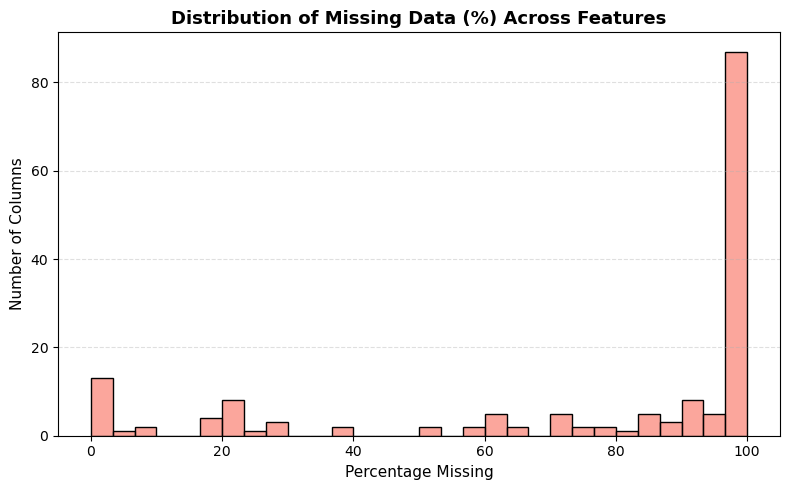

In [6]:
import pandas as pd

missing_summary = df.isna().sum() / len(df) * 100

missing_summary = missing_summary.to_frame(name="Missing %").reset_index()
missing_summary.columns = ["Feature", "Missing %"]

plt.figure(figsize=(8, 5))
sns.histplot(
    missing_summary["Missing %"],
    bins=30,
    color="salmon",
    edgecolor="black",
    alpha=0.7
)
plt.title("Distribution of Missing Data (%) Across Features", fontsize=13, weight='bold')
plt.xlabel("Percentage Missing", fontsize=11)
plt.ylabel("Number of Columns", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [6]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356027 entries, 0 to 356026
Columns: 163 entries, code to water-hardness_100g
dtypes: float64(107), object(56)
memory usage: 442.8+ MB


,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,...,fruits-vegetables-nuts_100g,fruits-vegetables-nuts-estimate_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
count,356001,356001,356024,356024,356017,356027,356027,338515,57714,119285,...,3228.000000,404.000000,182.000000,1383.000000,0.0,278.000000,254856.000000,254856.000000,0.0,0.0
unique,356001,356001,3890,224751,224752,216836,216836,249245,42451,15563,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0000000003087,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489055829,2017-03-09T10:37:09Z,1439141742,2015-08-09T17:35:42Z,Ice Cream,Pâtes alimentaires au blé dur de qualité supér...,500 g,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,169868,20,20,30,30,411,201,5285,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,33.392680,60.360124,15.362637,52.102675,NaN,335.790664,9.166137,8.980656,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.906834,29.262350,3.692658,19.028361,NaN,423.244817,8.999870,9.151757,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,8.000000,6.000000,NaN,0.000000,-15.000000,-15.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,45.000000,12.000000,33.000000,NaN,82.650000,1.000000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25.000000,58.000000,15.000000,52.000000,NaN,190.950000,10.000000,9.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55.000000,93.000000,15.000000,70.000000,NaN,378.700000,16.000000,16.000000,NaN,NaN


In [7]:
df = pd.read_csv(
    "en.openfoodfacts.org.products.tsv",
    sep='\t',
    low_memory=False,
    on_bad_lines='skip'
)

In [8]:
print(f"Rows loaded: {len(df):,}")

Rows loaded: 356,027


The OpenFoodFacts dataset contains 356,028 food products with 163 attributes.
After validating the file integrity, only 1 row were found malformed, indicating a high-quality, well-structured dataset suitable for machine learning preprocessing.

In [9]:
print(df.shape)
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
}).sort_values(by="Percentage (%)", ascending=False)
display(missing_df)

(356027, 163)


,Missing Values,Percentage (%)
water-hardness_100g,356027,100.000000
nutrition_grade_uk,356027,100.000000
-nervonic-acid_100g,356027,100.000000
-erucic-acid_100g,356027,100.000000
-mead-acid_100g,356027,100.000000
...,...,...
created_datetime,10,0.002809
created_t,3,0.000843
creator,3,0.000843
last_modified_datetime,0,0.000000


In [10]:
missing_100 = missing_percent[missing_percent == 100].sort_values(ascending=False)
print(f"Number of features with 100% missing: {len(missing_100)}")
display(missing_100)

Number of features with 100% missing: 16


no_nutriments                            100.0
ingredients_from_palm_oil                100.0
ingredients_that_may_be_from_palm_oil    100.0
nutrition_grade_uk                       100.0
-butyric-acid_100g                       100.0
-caproic-acid_100g                       100.0
-lignoceric-acid_100g                    100.0
-cerotic-acid_100g                       100.0
-melissic-acid_100g                      100.0
-elaidic-acid_100g                       100.0
-mead-acid_100g                          100.0
-erucic-acid_100g                        100.0
-nervonic-acid_100g                      100.0
chlorophyl_100g                          100.0
glycemic-index_100g                      100.0
water-hardness_100g                      100.0
dtype: float64

### Removing Columns with 100% Missing Values

During this stage, we identified all characteristics in the OpenFoodFacts data that had **100% missing values**. The characteristics fell into two categories; either very specific such as single fatty acids, chlorophyll, blood sugar index; or they were older features like nutrition_grade_uk or palm-oil related ingredients. 

Since these characteristics had zero recorded data points on them across the dataset; there were no analyses that could be performed to gain predictive power with these characteristics for exploratory data analysis or machine learning.  Therefore we are left with only noise and dimension to the data.

We therefore could safely remove the **16 characteristics** to streamline the dataset for analysis, model building, to focus on important characteristics that could potentially yield valuable information.

By removing the 16 characteristics, we improved the effort in three major areas:
- Data quality - we removed useless and empty variable
- Model efficiency - we are reducing irrelevant dimensions
- Interpretability - we are keeping only informative features for further analysis.

In [11]:
cols_100_missing = [
    'no_nutriments',
    'ingredients_from_palm_oil',
    'ingredients_that_may_be_from_palm_oil',
    'nutrition_grade_uk',
    '-butyric-acid_100g',
    '-caproic-acid_100g',
    '-lignoceric-acid_100g',
    '-cerotic-acid_100g',
    '-melissic-acid_100g',
    '-elaidic-acid_100g',
    '-mead-acid_100g',
    '-erucic-acid_100g',
    '-nervonic-acid_100g',
    'chlorophyl_100g',
    'glycemic-index_100g',
    'water-hardness_100g'
]

df = df.drop(columns=cols_100_missing)
print(f"Dataset now has {df.shape[1]} columns after removing 100%-missing features.")

Dataset now has 147 columns after removing 100%-missing features.


In [ ]:
missing_over_80 = missing_percent[missing_percent > 80].sort_values(ascending=False)
print(f"Number of features with 80% missing: {len(missing_over_80)}")
display(missing_over_80)

### Removing Columns with More than 80% Missing Values
After analyzing the data, we found a total of 109 features with over 80% missing data. Most of the variables were related to some rare nutrient or assessed some unique property that would really only relate to a very small set of products.

In the interests of quality data and preventing sparsity we deleted any column with over "80%" missing data. This means our analysis can focus on variables that are consistently present across products or at least the products included in the analyses based on what there is to analyze, and not have the burden of unreliable variables that would ultimately contribute noise to our model.

By restricting analysis to the highest level of completeness and most relevant features we can improve both computational efficiency and the ability to interpret and make sense of our results.

In [12]:
high_missing = df.columns[df.isnull().mean() > 0.8]
df.drop(columns=high_missing, inplace=True)
print(f"Dropped {len(high_missing)} columns with >80% missing values.")

Dropped 93 columns with >80% missing values.


In [13]:
for col in df.columns:
    print(col)

code
url
creator
created_t
created_datetime
last_modified_t
last_modified_datetime
product_name
quantity
packaging
packaging_tags
brands
brands_tags
categories
categories_tags
categories_en
countries
countries_tags
countries_en
ingredients_text
serving_size
additives_n
additives
additives_tags
additives_en
ingredients_from_palm_oil_n
ingredients_that_may_be_from_palm_oil_n
nutrition_grade_fr
pnns_groups_1
pnns_groups_2
states
states_tags
states_en
main_category
main_category_en
image_url
image_small_url
energy_100g
fat_100g
saturated-fat_100g
trans-fat_100g
cholesterol_100g
carbohydrates_100g
sugars_100g
fiber_100g
proteins_100g
salt_100g
sodium_100g
vitamin-a_100g
vitamin-c_100g
calcium_100g
iron_100g
nutrition-score-fr_100g
nutrition-score-uk_100g


In [14]:
df.shape

(356027, 54)

In [15]:
print("Before:", len(df))
df.drop_duplicates(subset=['code'], inplace=True)
print("After:", len(df))

Before: 356027
After: 356002


25 duplicates

In [16]:
num_cols = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g', 'trans-fat_100g',
    'cholesterol_100g', 'carbohydrates_100g', 'sugars_100g',
    'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g',
    'vitamin-a_100g', 'vitamin-c_100g', 'calcium_100g', 'iron_100g',
    'nutrition-score-fr_100g', 'nutrition-score-uk_100g'
]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

In [17]:
meta_cols = ['url', 'image_url', 'image_small_url', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime']
df.drop(columns=meta_cols, inplace=True)

In [18]:
df['brands'] = df['brands'].str.lower().str.strip()
df['countries_en'] = df['countries_en'].str.lower().str.strip()
df['main_category_en'] = df['main_category_en'].str.lower().str.strip()

In [19]:
df['nutrition_grade_fr'].value_counts()
df.groupby('pnns_groups_1')['nutrition_grade_fr'].value_counts(normalize=True)

pnns_groups_1            nutrition_grade_fr
Beverages                e                     0.453196
                         c                     0.214910
                         d                     0.166158
                         b                     0.129725
                         a                     0.036011
Cereals and potatoes     a                     0.494667
                         c                     0.200120
                         b                     0.166327
                         d                     0.122349
                         e                     0.016537
Composite foods          b                     0.313717
                         c                     0.285251
                         a                     0.225664
                         d                     0.160472
                         e                     0.014897
Fat and sauces           d                     0.492081
                         c                     0.236321
    

Before the exploratory data analysis (EDA) began, a number of preprocessing steps were executed to make sure that the dataset is consistent and ready for statistical and visual insights:

- Removed duplicates based on product code to eliminate bias from duplicate records. 
- Converted all nutritional columns (e.g., energy_100g, sugars_100g, proteins_100g) to numeric type so sustainable quantitative analysis may be performed. 
- Dropped unanalytical metadata like timestamps and URLs that would not help with modeling and exploration. 
- Lowercased text-based categorical fields like brand and country names to make grouping/aggregating cleaner. 
- Identified the target variable (nutrition_grade_fr) which would be used when exploring health-related outcomes across product categories, countries, and nutrient composition.

These steps allowed for a clean, consistent, and useful dataset from which exploratory insights were obtained.

In [20]:
for col in df.columns:
    print(col)

code
creator
product_name
quantity
packaging
packaging_tags
brands
brands_tags
categories
categories_tags
categories_en
countries
countries_tags
countries_en
ingredients_text
serving_size
additives_n
additives
additives_tags
additives_en
ingredients_from_palm_oil_n
ingredients_that_may_be_from_palm_oil_n
nutrition_grade_fr
pnns_groups_1
pnns_groups_2
states
states_tags
states_en
main_category
main_category_en
energy_100g
fat_100g
saturated-fat_100g
trans-fat_100g
cholesterol_100g
carbohydrates_100g
sugars_100g
fiber_100g
proteins_100g
salt_100g
sodium_100g
vitamin-a_100g
vitamin-c_100g
calcium_100g
iron_100g
nutrition-score-fr_100g
nutrition-score-uk_100g


In [21]:
print("=== DATASET OVERVIEW ===")
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n=== DATA TYPES AND MISSING VALUES ===")
df.info()

print("\n=== SUMMARY STATISTICS ===")
display(df.describe())

print("\n=== SAMPLE DATA ===")
display(df.head())

=== DATASET OVERVIEW ===
Dataset shape: (356002, 47)
Memory usage: 1325.19 MB

=== DATA TYPES AND MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
Int64Index: 356002 entries, 0 to 356026
Data columns (total 47 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   code                                     356001 non-null  object 
 1   creator                                  355999 non-null  object 
 2   product_name                             338490 non-null  object 
 3   quantity                                 119262 non-null  object 
 4   packaging                                89959 non-null   object 
 5   packaging_tags                           89959 non-null   object 
 6   brands                                   326977 non-null  object 
 7   brands_tags                              326957 non-null  object 
 8   categories                               103276 non-null 

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
count,283867.000000,283867.000000,283867.000000,295367.000000,2.794970e+05,263823.000000,143443.000000,144170.000000,2.792200e+05,279186.000000,2.206830e+05,2.941420e+05,289739.000000,289694.000000,137706.000000,141060.000000,141517.000000,140660.000000,254856.000000,254856.000000
mean,1.876851,0.023430,0.059736,1125.453320,5.606587e+04,5.092460,0.073487,0.020065,5.614020e+04,15.673428,3.843467e+05,5.326942e+04,1.941281,0.764401,0.000398,0.023394,0.127284,0.003791,9.166137,8.980656
std,2.501022,0.153094,0.280660,936.825952,2.963385e+07,7.965148,1.539417,0.357963,2.964854e+07,21.983635,1.805529e+08,2.888671e+07,120.545973,47.462729,0.073239,2.234928,3.349236,0.216565,8.999870,9.151757
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-3.570000,0.000000,0.000000e+00,-17.860000,-6.700000e+00,-8.000000e+02,0.000000,0.000000,-0.000340,-0.002100,0.000000,-0.000260,-15.000000,-15.000000
25%,0.000000,0.000000,0.000000,382.000000,1.000000e-01,0.000000,0.000000,0.000000,5.600000e+00,1.200000,0.000000e+00,7.200000e-01,0.060000,0.023622,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,1.000000,0.000000,0.000000,1092.000000,5.290000e+00,1.790000,0.000000,0.000000,2.000000e+01,5.400000,1.500000e+00,4.880000e+00,0.558800,0.220000,0.000000,0.000000,0.036000,0.001010,10.000000,9.000000
75%,3.000000,0.000000,0.000000,1674.000000,2.000000e+01,7.140000,0.000000,0.020000,5.758000e+01,23.330000,3.600000e+00,1.000000e+01,1.356360,0.534000,0.000107,0.003800,0.107000,0.002400,16.000000,16.000000
max,30.000000,2.000000,6.000000,231199.000000,1.566667e+10,550.000000,369.000000,95.238000,1.566667e+10,3520.000000,8.481815e+10,1.566667e+10,64312.800000,25320.000000,26.700000,716.981100,694.737000,50.000000,40.000000,40.000000



=== SAMPLE DATA ===


,code,creator,product_name,quantity,packaging,packaging_tags,brands,brands_tags,categories,categories_tags,...,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
0,0000000003087,openfoodfacts-contributors,Farine de blé noir,1kg,NaN,NaN,ferme t'y r'nao,ferme-t-y-r-nao,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000000004530,usda-ndb-import,Banana Chips Sweetened (Whole),NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.6,3.57,0.00000,0.000,0.0,0.0214,0.000,0.00129,14.0,14.0
2,0000000004559,usda-ndb-import,Peanuts,NaN,NaN,NaN,torn & glasser,torn-glasser,NaN,NaN,...,7.1,17.86,0.63500,0.250,0.0,0.0000,0.071,0.00129,0.0,0.0
3,0000000016087,usda-ndb-import,Organic Salted Nut Mix,NaN,NaN,NaN,grizzlies,grizzlies,NaN,NaN,...,7.1,17.86,1.22428,0.482,NaN,NaN,0.143,0.00514,12.0,12.0
4,0000000016094,usda-ndb-import,Organic Polenta,NaN,NaN,NaN,bob's red mill,bob-s-red-mill,NaN,NaN,...,5.7,8.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
print("=== MISSING DATA ANALYSIS ===")
missing_counts = df.isnull().sum()
missing_summary = pd.DataFrame({
    "Missing Values": missing_counts,
    "Missing %": (missing_counts / len(df)) * 100
}).sort_values(by="Missing %", ascending=False)

display(missing_summary[missing_summary["Missing Values"] > 0])

=== MISSING DATA ANALYSIS ===


,Missing Values,Missing %
packaging,266043,74.730760
packaging_tags,266043,74.730760
main_category,252753,70.997635
main_category_en,252753,70.997635
categories_tags,252727,70.990332
categories_en,252726,70.990051
categories,252726,70.990051
quantity,236740,66.499626
pnns_groups_1,226996,63.762563
pnns_groups_2,223313,62.728018


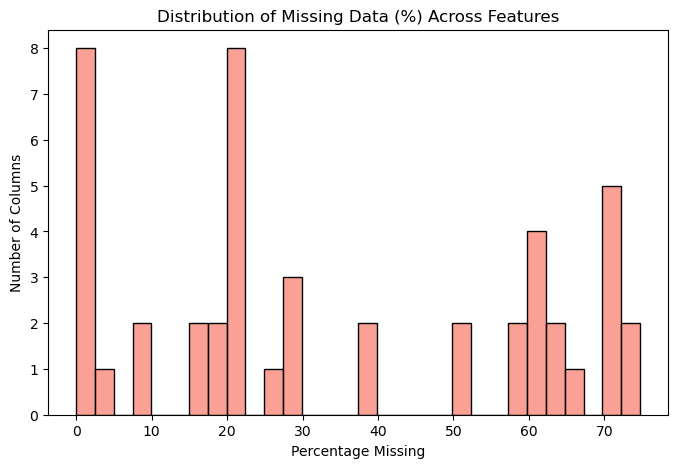

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(missing_summary["Missing %"], bins=30, color="salmon")
plt.title("Distribution of Missing Data (%) Across Features")
plt.xlabel("Percentage Missing")
plt.ylabel("Number of Columns")
plt.show()

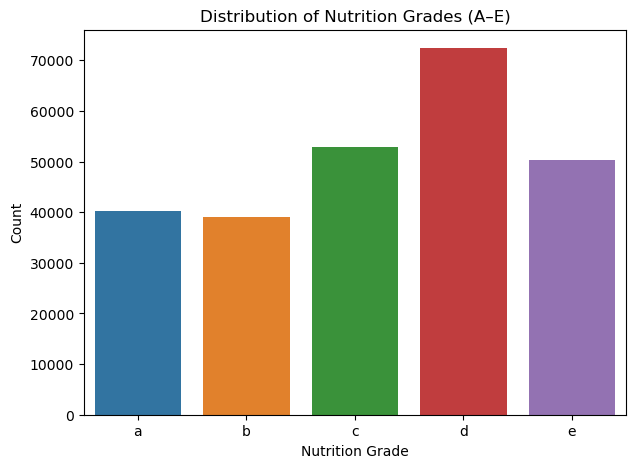

In [24]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='nutrition_grade_fr', order=sorted(df['nutrition_grade_fr'].dropna().unique()))
plt.title("Distribution of Nutrition Grades (A–E)")
plt.xlabel("Nutrition Grade")
plt.ylabel("Count")
plt.show()


In [25]:
for col in ['energy_100g','fat_100g','saturated-fat_100g','sugars_100g','salt_100g']:
    print(col, "max:", df[col].max(), " | min:", df[col].min())

energy_100g max: 231199.0  | min: 0.0
fat_100g max: 15666666000.0  | min: 0.0
saturated-fat_100g max: 550.0  | min: 0.0
sugars_100g max: 3520.0  | min: -17.86
salt_100g max: 64312.8  | min: 0.0


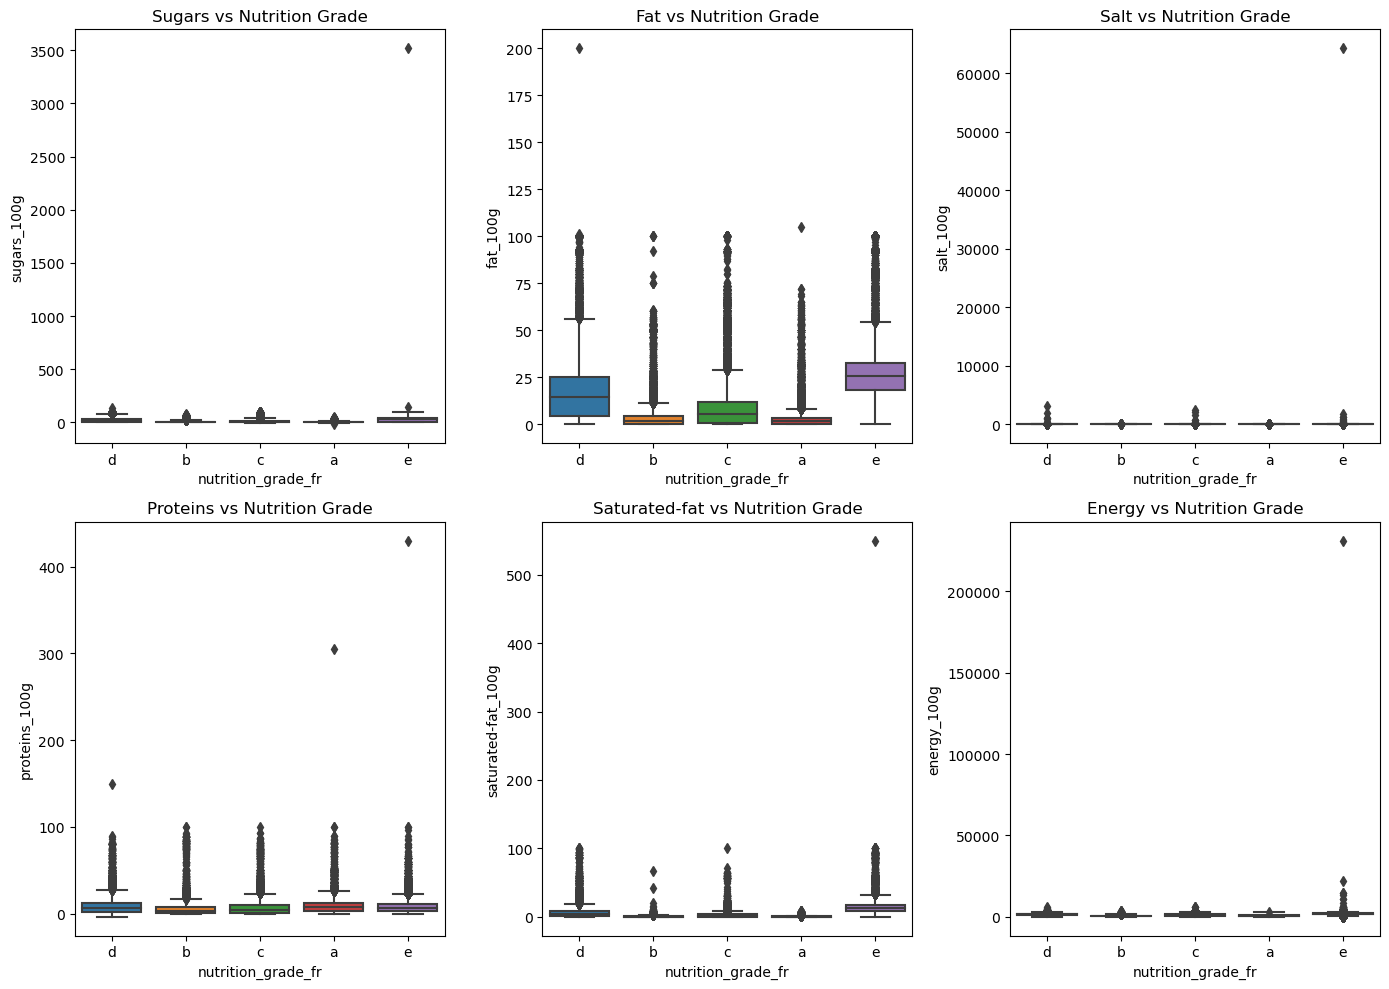

In [26]:
plt.figure(figsize=(14,10))
nutrients = ['sugars_100g', 'fat_100g', 'salt_100g', 'proteins_100g', 'saturated-fat_100g', 'energy_100g']
for i, col in enumerate(nutrients, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='nutrition_grade_fr', y=col)
    plt.title(f"{col.replace('_100g','').capitalize()} vs Nutrition Grade")
plt.tight_layout()
plt.show()

Before examining nutrient distributions, it was necessary to eliminate physically improbable or corrupt values. Some entries had extreme outliers such as fat_100g = 15,666,666,000 or salt_100g = 64,000, which is clearly a result of a data-entry or parsing error. 

To allow for accurate and meaningful analyses, I capped the nutrient columns within scientifically valid ranges (e.g., energy ≤ 4000 kcal/100g, fat ≤ 100g/100g). All values outside this range were substituted with NaN. 

Performing this step will ensure higher fidelity to the visualizations, but most importantly while performing analyses further on (boxplots, correalation), we are likely to be dealing with real information about food products and not simply noise. 

In [27]:
valid_ranges = {
    'energy_100g': (0, 20000),           
    'fat_100g': (0, 120),               
    'saturated-fat_100g': (0, 110),     
    'sugars_100g': (0, 150),           
    'proteins_100g': (0, 120),          
    'salt_100g': (0, 4000)                
}

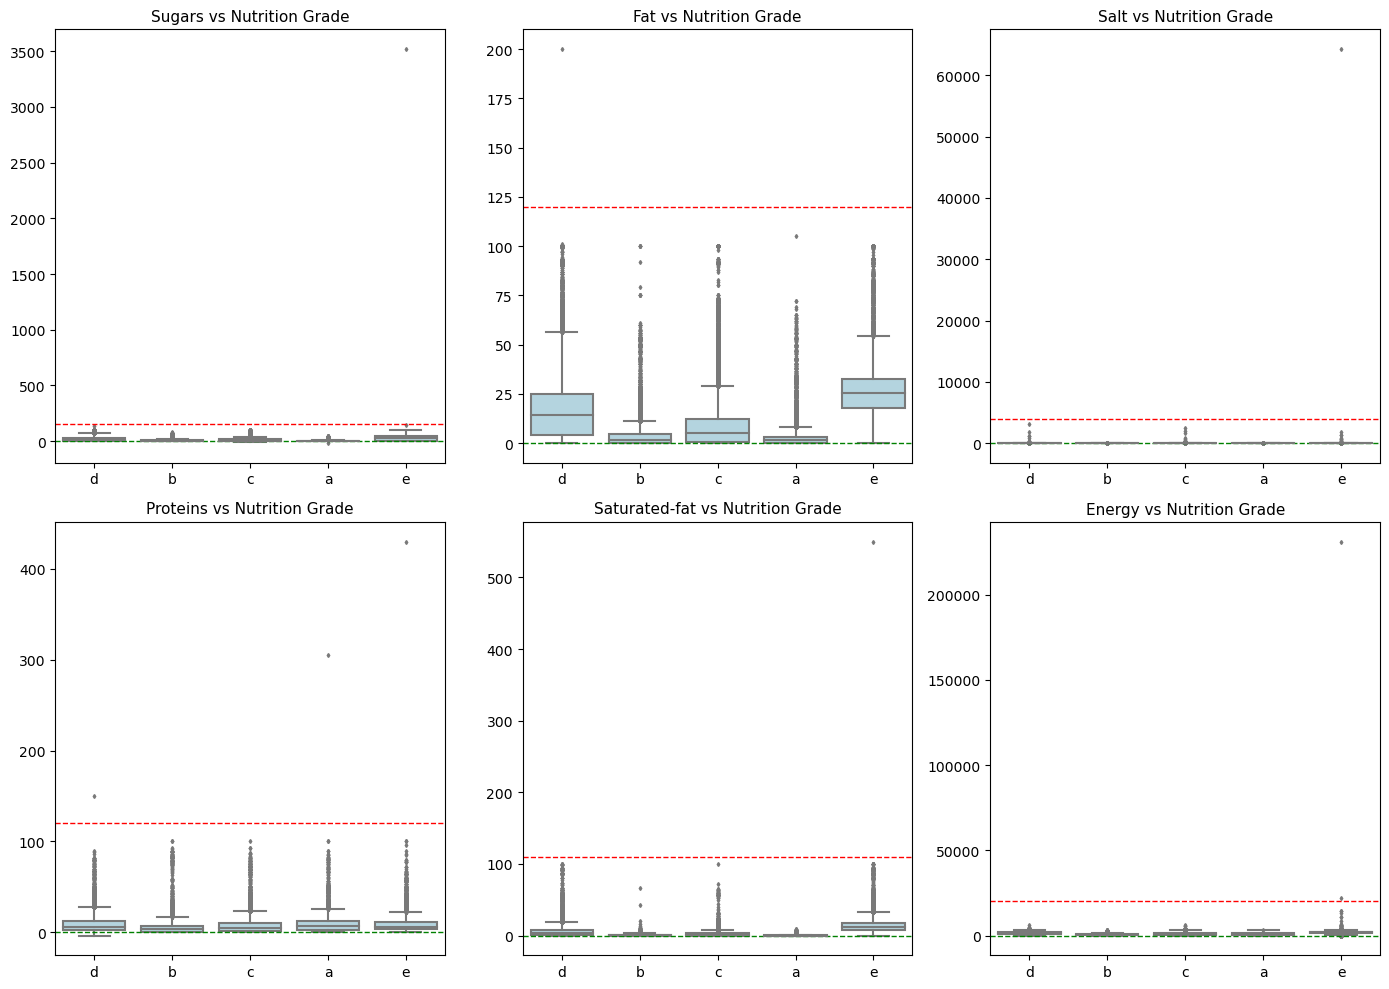

In [28]:
plt.figure(figsize=(14, 10))
nutrients = ['sugars_100g', 'fat_100g', 'salt_100g', 
             'proteins_100g', 'saturated-fat_100g', 'energy_100g']

for i, col in enumerate(nutrients, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='nutrition_grade_fr', y=col, color='lightblue', fliersize=2)
    vmin, vmax = valid_ranges[col]
    plt.axhline(vmin, color='green', linestyle='--', linewidth=1)
    plt.axhline(vmax, color='red', linestyle='--', linewidth=1)
    plt.title(f"{col.replace('_100g','').capitalize()} vs Nutrition Grade", fontsize=11)
    plt.ylabel("")
    plt.xlabel("")

plt.tight_layout()
plt.show()

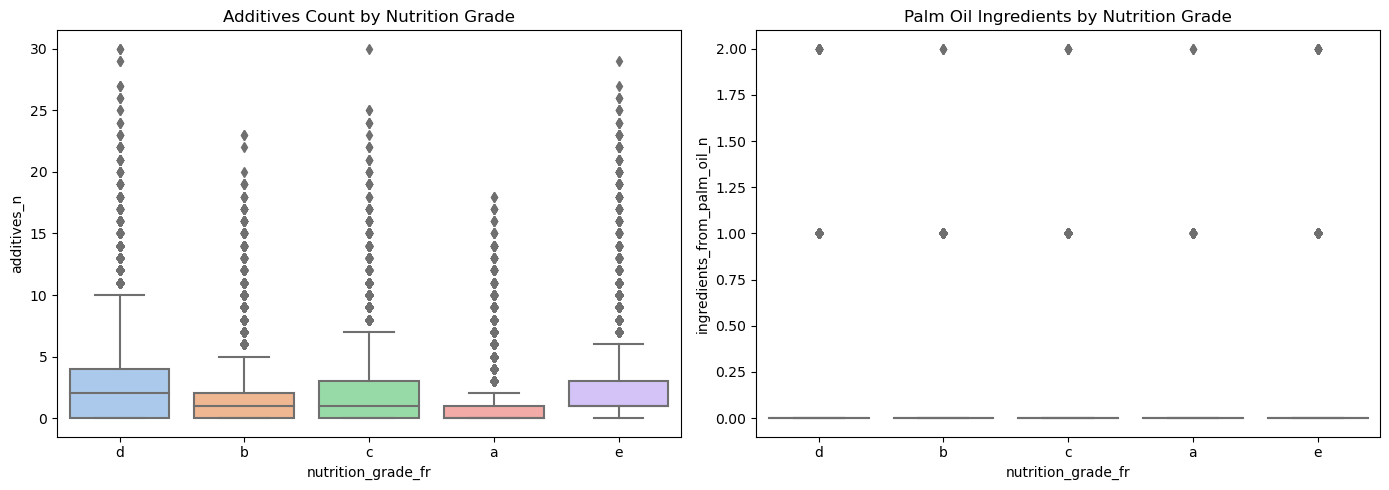

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='nutrition_grade_fr', y='additives_n', ax=axes[0], palette='pastel')
axes[0].set_title("Additives Count by Nutrition Grade")

sns.boxplot(data=df, x='nutrition_grade_fr', y='ingredients_from_palm_oil_n', ax=axes[1], palette='pastel')
axes[1].set_title("Palm Oil Ingredients by Nutrition Grade")

plt.tight_layout()
plt.show()

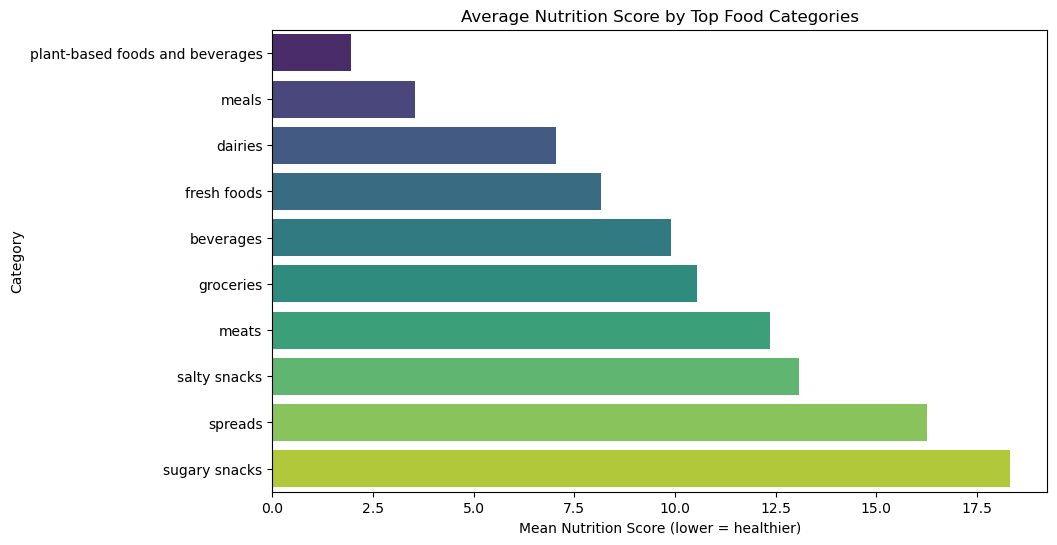

In [30]:
top_cats = df['main_category_en'].value_counts().head(10).index
avg_scores = (df[df['main_category_en'].isin(top_cats)]
              .groupby('main_category_en')['nutrition-score-fr_100g']
              .mean()
              .sort_values())

plt.figure(figsize=(10,6))
sns.barplot(x=avg_scores.values, y=avg_scores.index, palette="viridis")
plt.title("Average Nutrition Score by Top Food Categories")
plt.xlabel("Mean Nutrition Score (lower = healthier)")
plt.ylabel("Category")
plt.show()

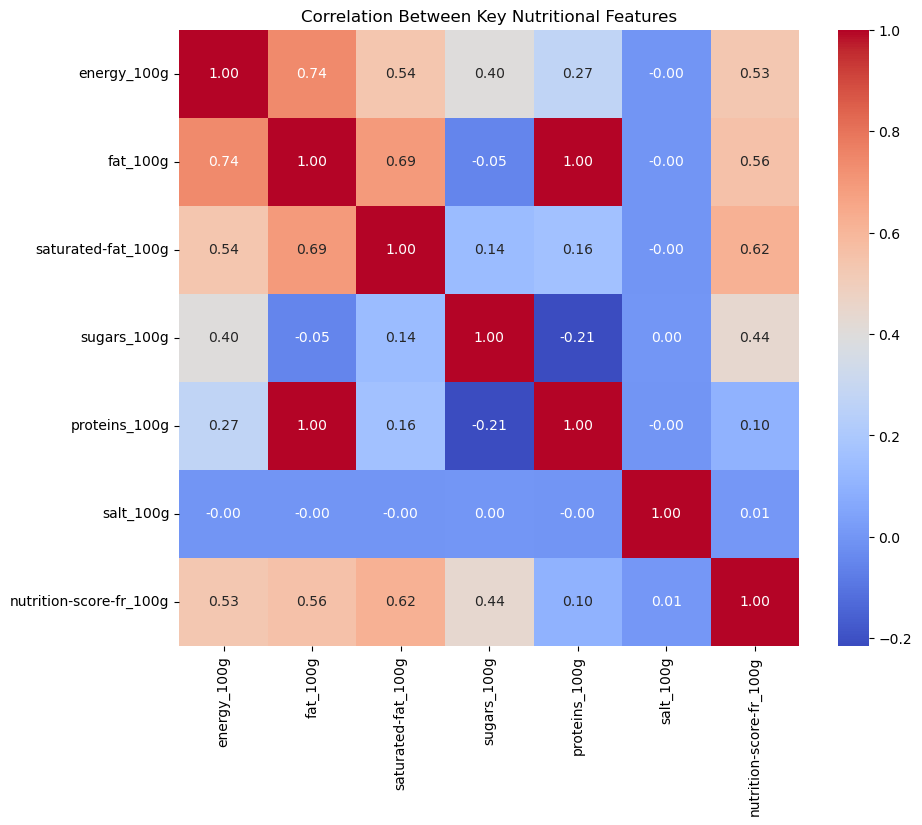

In [31]:
plt.figure(figsize=(10,8))
corr = df[['energy_100g','fat_100g','saturated-fat_100g','sugars_100g',
           'proteins_100g','salt_100g','nutrition-score-fr_100g']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Key Nutritional Features")
plt.show()

In [32]:
for col, (vmin, vmax) in valid_ranges.items():
    before = len(df)
    df = df[(df[col].between(vmin, vmax)) | (df[col].isna())]
    after = len(df)
    print(f"{col}: removed {before - after} rows outside range ({vmin}, {vmax})")

print(f"\nRemaining rows after cleaning: {len(df)}")

energy_100g: removed 5 rows outside range (0, 20000)
fat_100g: removed 2 rows outside range (0, 120)
saturated-fat_100g: removed 1 rows outside range (0, 110)
sugars_100g: removed 8 rows outside range (0, 150)
proteins_100g: removed 5 rows outside range (0, 120)
salt_100g: removed 1 rows outside range (0, 4000)

Remaining rows after cleaning: 355980


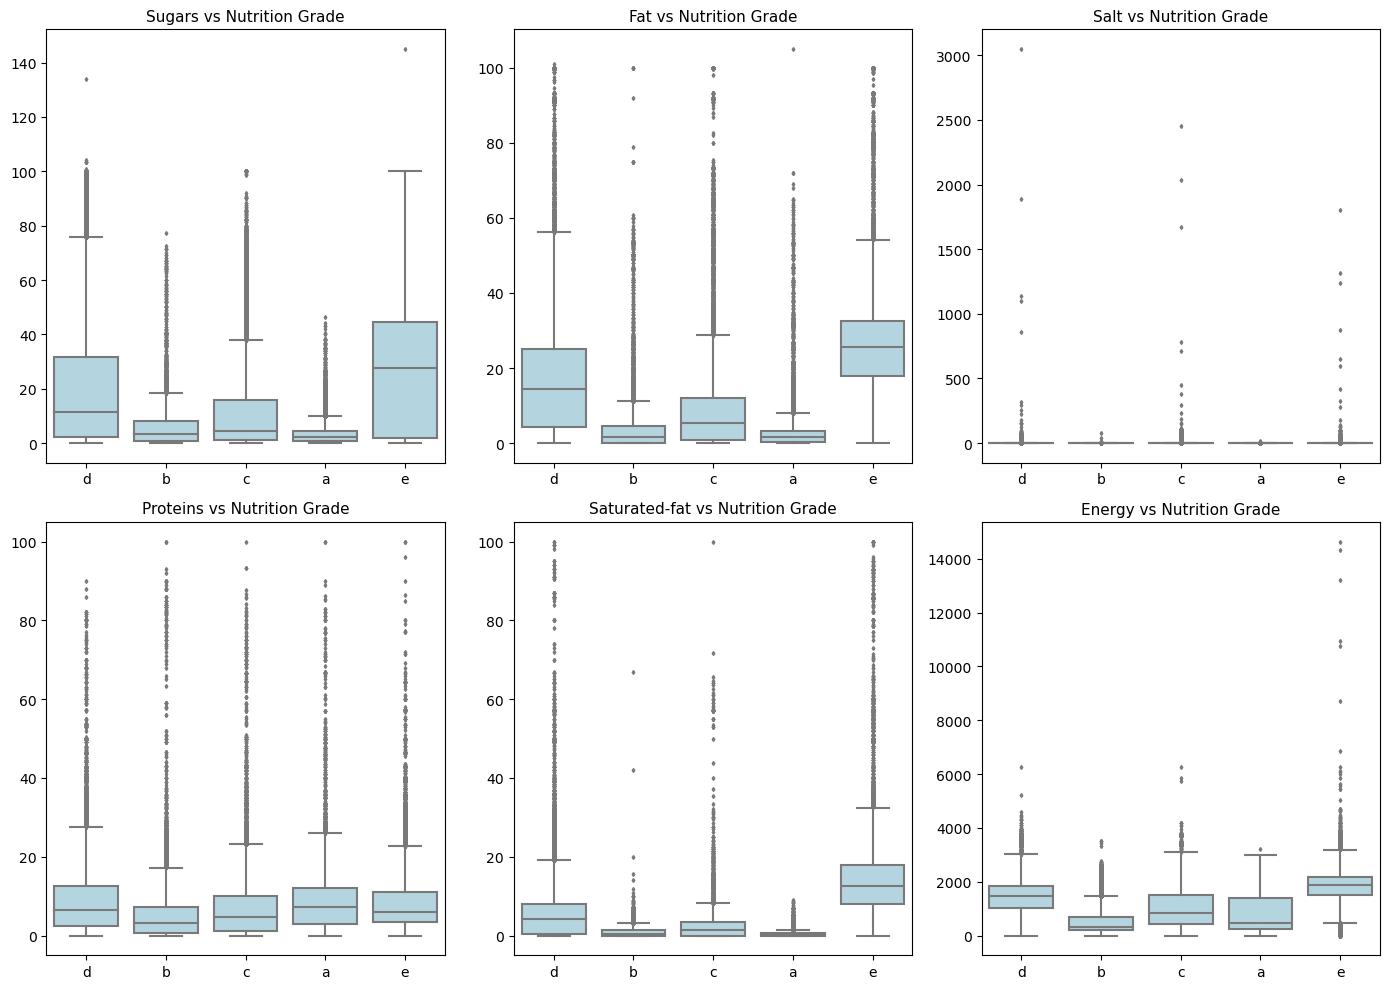

In [33]:
plt.figure(figsize=(14, 10))
nutrients = ['sugars_100g', 'fat_100g', 'salt_100g', 
             'proteins_100g', 'saturated-fat_100g', 'energy_100g']

for i, col in enumerate(nutrients, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='nutrition_grade_fr', y=col, color='lightblue', fliersize=2)
    vmin, vmax = valid_ranges[col]
    plt.title(f"{col.replace('_100g','').capitalize()} vs Nutrition Grade", fontsize=11)
    plt.ylabel("")
    plt.xlabel("")

plt.tight_layout()
plt.show()


In [34]:
display(df.describe())

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
count,283850.000000,283850.000000,283850.000000,295348.000000,279478.000000,263808.000000,143434.000000,144160.000000,279200.000000,279169.000000,2.206690e+05,294122.000000,289720.000000,289675.000000,137699.000000,141053.000000,141508.000000,140653.000000,254844.000000,254844.000000
mean,1.876928,0.023431,0.059739,1123.903726,12.797460,5.089406,0.073491,0.020066,31.510462,15.660786,3.843711e+05,7.163108,1.718694,0.676755,0.000398,0.023395,0.127286,0.003791,9.166098,8.980588
std,2.501068,0.153098,0.280668,800.093319,17.507159,7.885131,1.539465,0.357975,28.986382,20.957440,1.805586e+08,8.261257,16.020259,6.307666,0.073241,2.234984,3.349342,0.216571,8.999733,9.151610
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.570000,0.000000,0.000000,0.000000,-6.700000e+00,0.000000,0.000000,0.000000,-0.000340,-0.002100,0.000000,-0.000260,-15.000000,-15.000000
25%,0.000000,0.000000,0.000000,382.000000,0.100000,0.000000,0.000000,0.000000,5.600000,1.200000,0.000000e+00,0.720000,0.060000,0.023622,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,1.000000,0.000000,0.000000,1092.000000,5.290000,1.790000,0.000000,0.000000,20.000000,5.400000,1.500000e+00,4.880000,0.558800,0.220000,0.000000,0.000000,0.036000,0.001010,10.000000,9.000000
75%,3.000000,0.000000,0.000000,1674.000000,20.000000,7.140000,0.000000,0.020000,57.580000,23.330000,3.600000e+00,10.000000,1.356360,0.534000,0.000107,0.003800,0.107000,0.002400,16.000000,16.000000
max,30.000000,2.000000,6.000000,16000.000000,105.000000,100.000000,369.000000,95.238000,209.380000,145.000000,8.481815e+10,100.000000,3556.000000,1400.000000,26.700000,716.981100,694.737000,50.000000,40.000000,40.000000


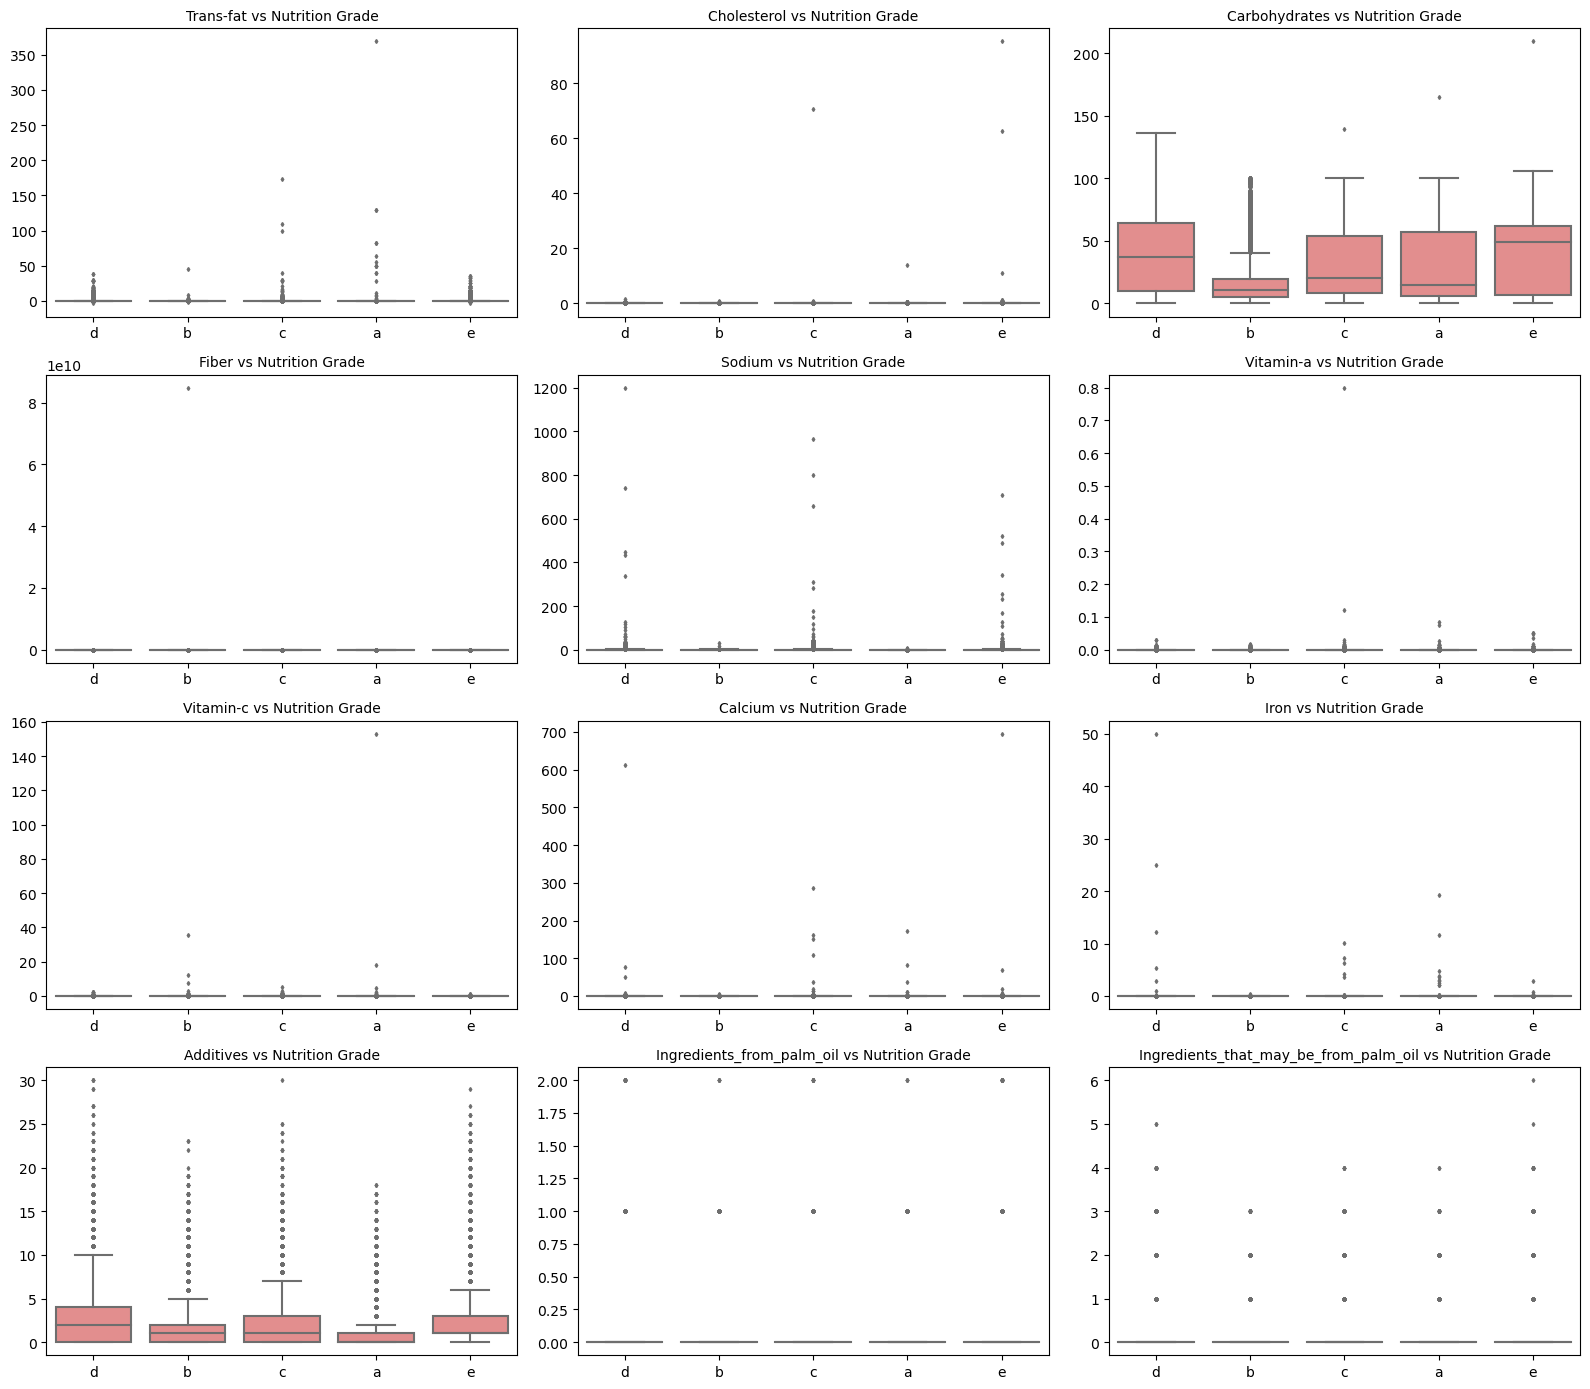

In [35]:
other_features = [
    'trans-fat_100g', 'cholesterol_100g', 'carbohydrates_100g', 'fiber_100g',
    'sodium_100g', 'vitamin-a_100g', 'vitamin-c_100g', 'calcium_100g',
    'iron_100g', 'additives_n', 'ingredients_from_palm_oil_n',
    'ingredients_that_may_be_from_palm_oil_n'
]

plt.figure(figsize=(16, 14))
for i, col in enumerate(other_features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=df, x='nutrition_grade_fr', y=col, color='lightcoral', fliersize=2)
    plt.title(f"{col.replace('_100g', '').replace('_n', '').capitalize()} vs Nutrition Grade", fontsize=10)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

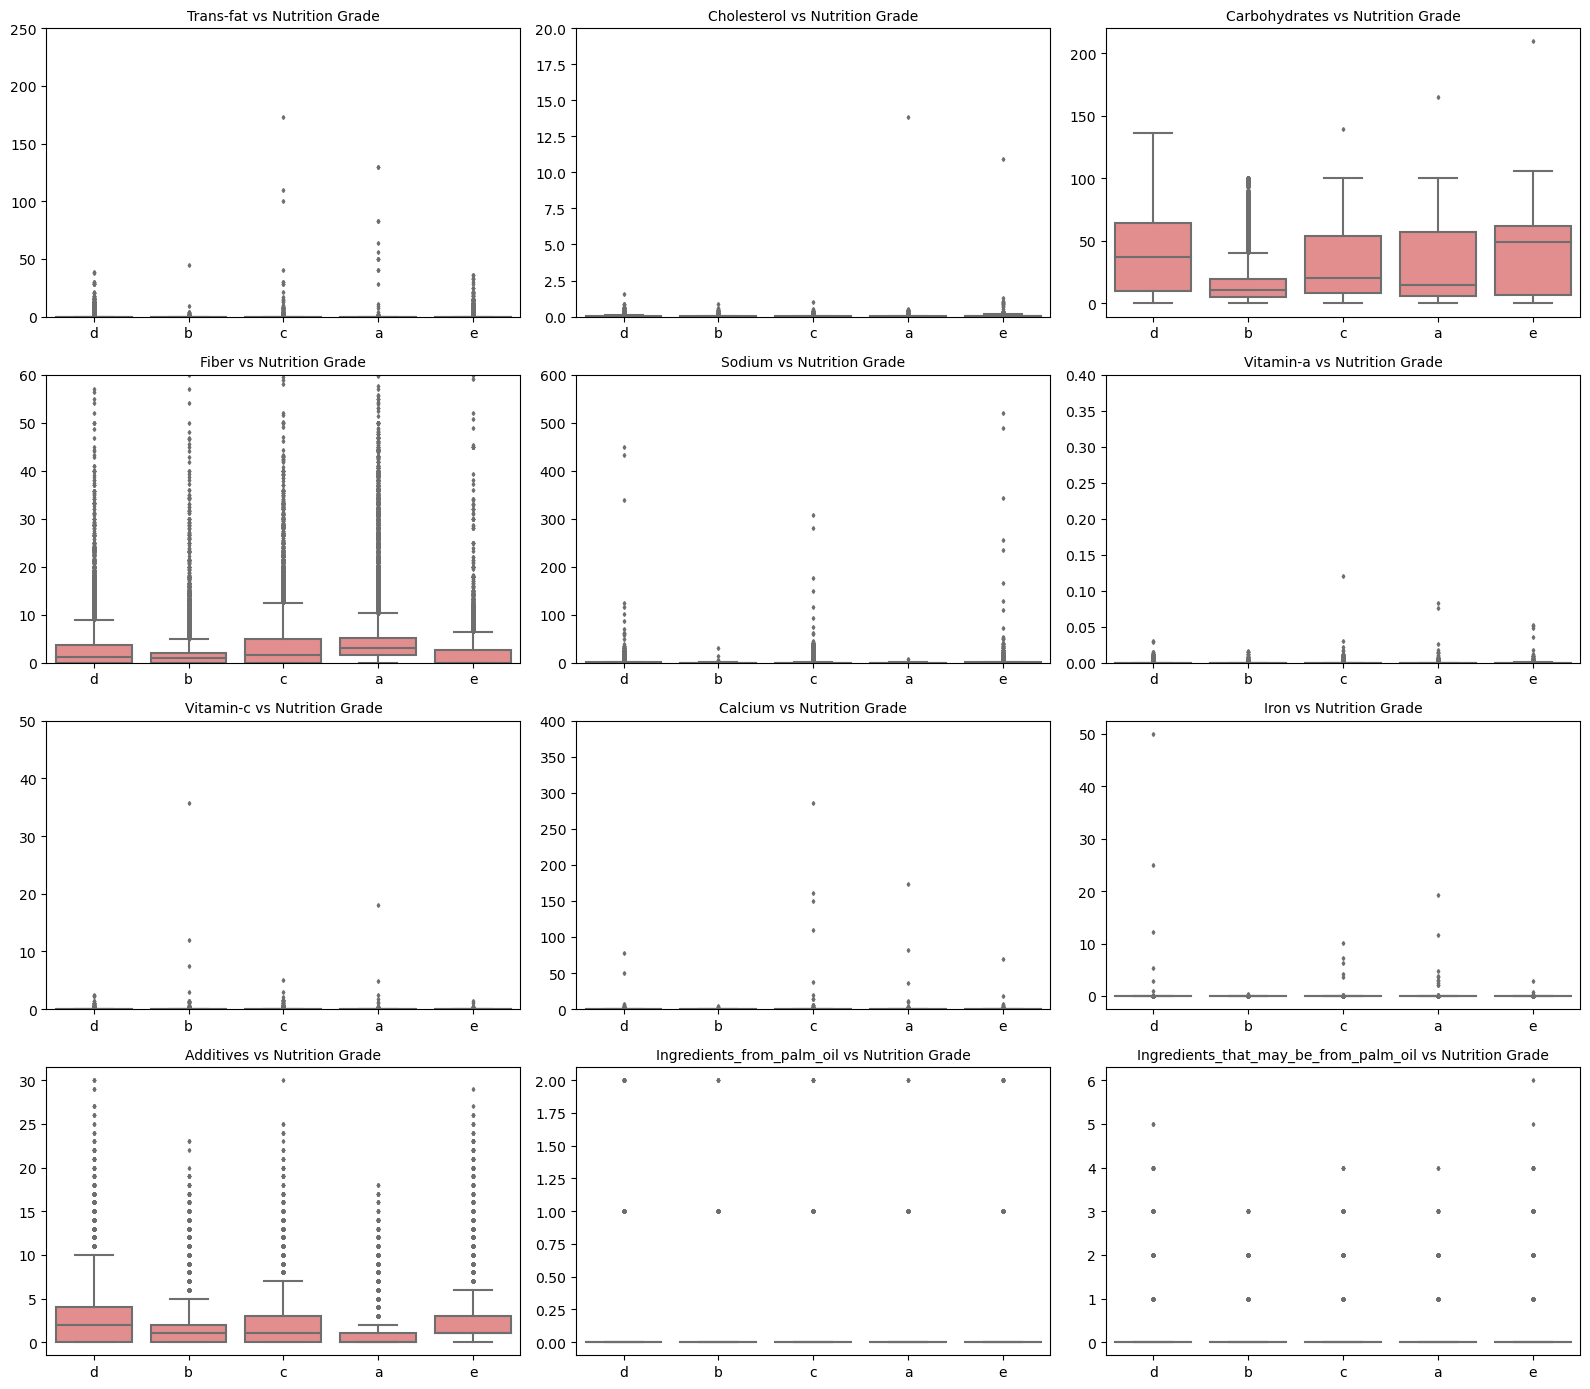

In [36]:
ylims = {
    'fiber_100g': (0, 60),
    'sodium_100g': (0, 600),
    'trans-fat_100g': (0, 250),
    'vitamin-a_100g': (0, 0.4),
    'vitamin-c_100g': (0, 50),
    'cholesterol_100g': (0,20),
    'calcium_100g': (0,400)
}

plt.figure(figsize=(16, 14))
for i, col in enumerate(other_features, 1):
    plt.subplot(4, 3, i)
    ax = sns.boxplot(data=df, x='nutrition_grade_fr', y=col, color='lightcoral', fliersize=2)
    if col in ylims and ylims[col] is not None:
        ax.set_ylim(*ylims[col])
    plt.title(f"{col.replace('_100g','').replace('_n','').capitalize()} vs Nutrition Grade", fontsize=10)
    plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.show()

In [37]:
supervised_features = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g', 'sugars_100g',
    'salt_100g', 'proteins_100g', 'carbohydrates_100g', 'fiber_100g',
    'cholesterol_100g', 'sodium_100g', 'vitamin-a_100g', 'vitamin-c_100g',
    'calcium_100g', 'iron_100g', 'trans-fat_100g', 'additives_n',
    'ingredients_from_palm_oil_n', 'ingredients_that_may_be_from_palm_oil_n',
    'pnns_groups_1', 'pnns_groups_2', 'main_category_en',
    'countries_en', 'nutrition_grade_fr'
]

df_supervised = df[supervised_features].dropna(subset=['nutrition_grade_fr'])

In [38]:
unsupervised_features = [
    'product_name', 'brands', 'categories_en', 'main_category_en',
    'additives_en', 'ingredients_text', 'countries_en',
    'energy_100g', 'fat_100g', 'saturated-fat_100g', 'sugars_100g',
    'salt_100g', 'proteins_100g', 'carbohydrates_100g', 'fiber_100g',
    'additives_n', 'nutrition_grade_fr'
]

df_unsupervised = df[unsupervised_features]

### Final Exploration

#### Checking for Final Duplicates

In [39]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate product names:", df['product_name'].duplicated().sum())

Duplicate rows: 0
Duplicate product names: 106750


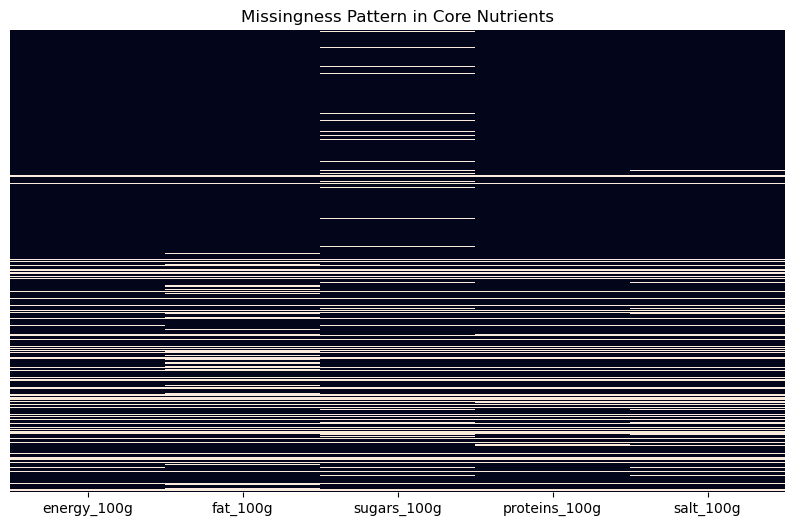

In [40]:
plt.figure(figsize=(10,6))
sns.heatmap(df[[
    'energy_100g','fat_100g','sugars_100g','proteins_100g','salt_100g'
]].isnull(), cbar=False, yticklabels=False)
plt.title("Missingness Pattern in Core Nutrients")
plt.show()


We investigated the missing values related to the core nutrients (energy_100g, fat_100g, sugars_100g, proteins_100g, and salt_100g). The heatmap suggests the missing values are not random - some nutrients are more commonly missing than others, and there are many products that are missing several nutrient values at once. This suggests joint missingness in which a specific product type has incomplete nutrition information because of how nutrition information was tracked for that product type. While we are not currently addressing the missing data, the heatmap will assist with our imputation strategy when we get to that stage of our data preparation.

### Obvious Inconsistensies 

In [41]:
invalid_fat = df[
    (df['saturated-fat_100g'] > df['fat_100g']) |
    ((df['fat_100g'] == 0) & (df['saturated-fat_100g'] > 0))
]
print(f"Invalid fat entries: {len(invalid_fat)}")

Invalid fat entries: 352


Saturated fat can't be greater than fat, so during our data preperation we must hamdle those 352 values.

In [42]:
invalid_carbs = df[df['sugars_100g'] > df['carbohydrates_100g']]
invalid_salt = df[(df['salt_100g']/df['sodium_100g']).between(2,3) == False]
print(f"Invalid carbs entries: {len(invalid_carbs)}")
print(f"Invalid salt entries: {len(invalid_salt)}")

Invalid carbs entries: 693
Invalid salt entries: 105014


In [43]:
grade_map = {'a':5, 'b':4, 'c':3, 'd':2, 'e':1}
df['grade_num'] = df['nutrition_grade_fr'].map(grade_map)

corr = df.corr(numeric_only=True)['grade_num'].sort_values(ascending=False)
print(corr.head(10))

grade_num           1.000000
vitamin-c_100g      0.009563
vitamin-a_100g      0.006502
fiber_100g          0.001788
iron_100g           0.001591
calcium_100g       -0.016304
trans-fat_100g     -0.020580
cholesterol_100g   -0.028937
salt_100g          -0.037971
sodium_100g        -0.037971
Name: grade_num, dtype: float64


The plot shows that none of the single nutrients — by themselves — explain the nutrition grade very strongly.
However, nutrients like sodium, salt, cholesterol, and trans-fat show a negative trend, meaning that higher values are associated with less healthy grades.
Vitamins and fiber show a weak positive relationship, consistent with healthier products.

### Distributions Before Cleaning

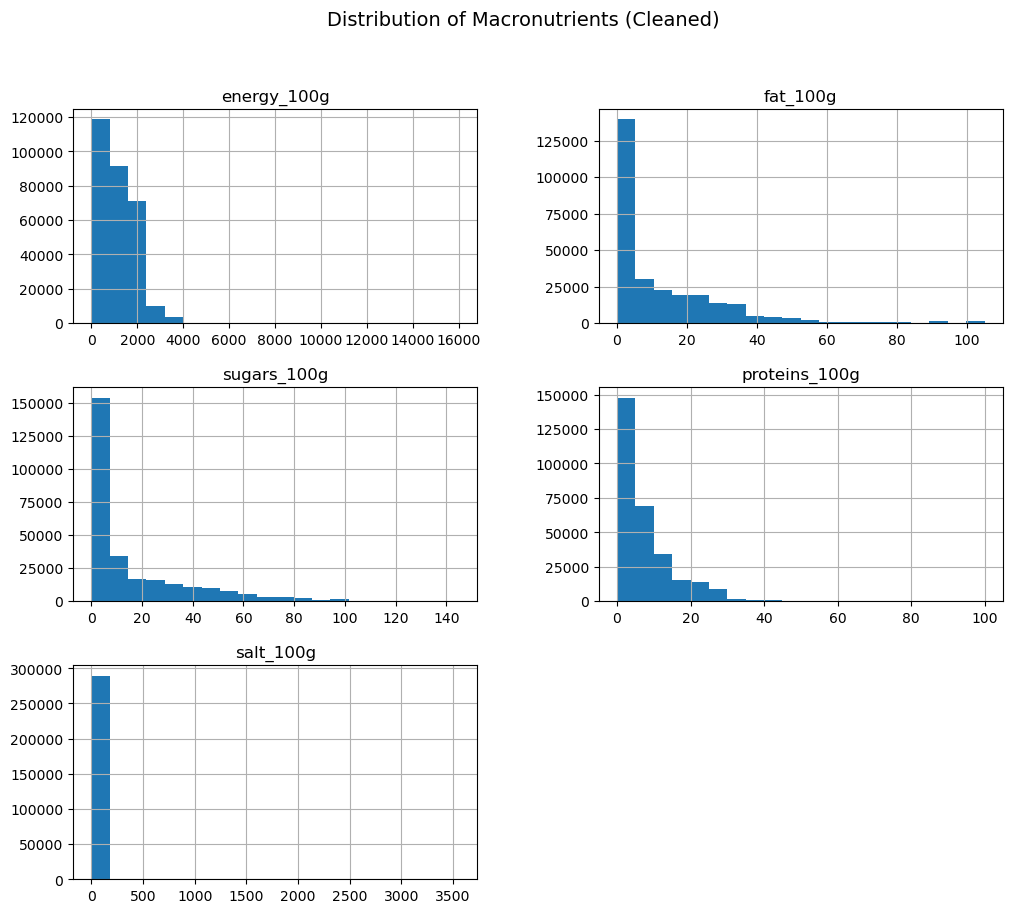

In [44]:
df[['energy_100g','fat_100g','sugars_100g','proteins_100g','salt_100g']].hist(bins=20, figsize=(12,10))
plt.suptitle("Distribution of Macronutrients (Cleaned)", fontsize=14)
plt.show()

In [45]:
cat_cols = ['brands', 'categories_en', 'main_category_en', 'countries_en']
for col in cat_cols:
    print(col, ":", df[col].nunique())

brands : 60197
categories_en : 24102
main_category_en : 3638
countries_en : 778


### Data Exploration Recap

In our data exploration, we looked for inconsistencies, relationships between variables, and the distribution of nutritional features. 

1. Data Quality and Logical Inconsistencies
- Fat composition is invalid: 352 products contained saturated fat that was greater than total fat (or for other products, fat = 0 while saturated fat was > 0). All of these will need to be addressed in the data preparation.
- Carbohydrates composition is invalid: 693 total entries had sugar that was greater than total carbohydrates. This error was likely based on an incorrect data-entry or confusion with the units used.
- Salt-sodium ratio is invalid: More than 100k rows had salt-to-sodium ratios greater than 100 or less than 1. This was due primarily to missing sodium values, 0 sodium values, or a units discrepancy (i.e. sodium could be reported in mg or g).
- Overall, we confirm through each of these checks that the dataset contained biologically inconsistent signals, which is typical of noise found in real-world food labels that will need to be cleaned before any modeling.

2. Correlation Insights
- By mapping nutrition grades (a–e) to numeric scores corresponding to the nutrition grade (5–1) we calculated correlations between nutrients and grade scores:
- Negative correlations: sodium, salt, cholesterol and trans-fat value were all negatively correlated with the nutrition grade score, meaning that when these values were higher, the grade, which indicates healthiness, was lower.
- Positive correlations (albeit weak): vitamins and fiber both demonstrated a small positive correlation, which suggests healthier foods have higher nutrients. 
- Overall: there were no single nutrient that strongly explained why some foods received a higher or lower nutrition grade. Instead, it appears the grade represented an interaction between multiple nutrients.

3. Distribution Patterns

Histograms for macronutrients (energy, fat, sugars, proteins, salt) show right-skewed distributions, meaning most foods contain relatively low nutrient amounts per 100g, with a few high-value outliers.
This pattern is typical for open food databases where nutrient reporting varies across products and categories.

4. Categorical Feature Diversity
- Key categorical features reveal substantial diversity:
- Brands: 60k unique values
- Categories (English): 24k
- Main Categories: ~3.6k
- Countries: 778

This indicates a highly diverse dataset spanning many regions and product types, which can be leveraged for clustering or regional nutritional analysis.

In [46]:
print("Missing sodium values:", df['sodium_100g'].isna().sum())
print("Zero sodium values:", (df['sodium_100g'] == 0).sum())
print("Missing salt values:", df['salt_100g'].isna().sum())
print("Zero salt values:", (df['salt_100g'] == 0).sum())

Missing sodium values: 66305
Zero sodium values: 38709
Missing salt values: 66260
Zero salt values: 38750


In [47]:
valid_salt_sodium = df[(df['sodium_100g'] > 0) & (df['salt_100g'] > 0)]
invalid_ratio = valid_salt_sodium[
    ~valid_salt_sodium['salt_100g'].div(valid_salt_sodium['sodium_100g']).between(2,3)
]
print("Invalid ratios among valid rows:", len(invalid_ratio))
print("Total valid ratio rows:", len(valid_salt_sodium))
print("Percent invalid among valid:", len(invalid_ratio) / len(valid_salt_sodium) * 100)

Invalid ratios among valid rows: 0
Total valid ratio rows: 250966
Percent invalid among valid: 0.0


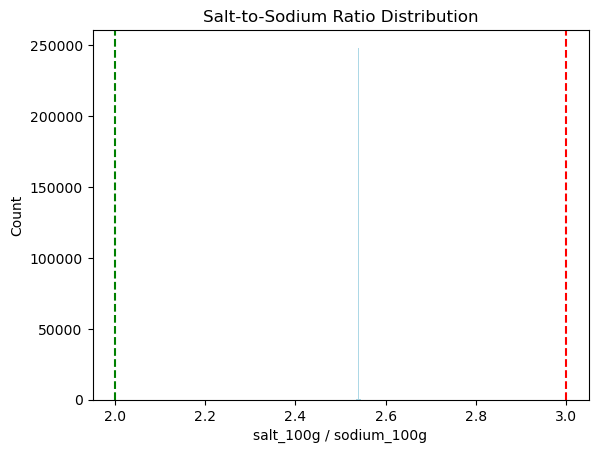

In [48]:
ratio = valid_salt_sodium['salt_100g'] / valid_salt_sodium['sodium_100g']
plt.hist(ratio, bins=50, color='lightblue')
plt.title("Salt-to-Sodium Ratio Distribution")
plt.xlabel("salt_100g / sodium_100g")
plt.ylabel("Count")
plt.axvline(2, color='green', linestyle='--')
plt.axvline(3, color='red', linestyle='--')
plt.show()

The apparent 10,000+ “invalid” salt-to-sodium entries were not true inconsistencies — they resulted from missing or zero sodium values.
The valid entries follow the expected chemical ratio of salt to sodium precisely, meaning the dataset is internally consistent.

### Data Preperation

#### Removing Inconsistent Value

In [49]:
df = df[~((df['saturated-fat_100g'] > df['fat_100g']) |
          ((df['fat_100g'] == 0) & (df['saturated-fat_100g'] > 0)))]

df = df[df['sugars_100g'] <= df['carbohydrates_100g']]

In [50]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_percent
})

missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

missing_summary = missing_summary.sort_values(by='Missing %', ascending=False)

styled_missing = (missing_summary
    .style
    .background_gradient(cmap='Greys', axis=None)
    .format({'Missing %': '{:.6f}'})
)

styled_missing

,Missing Values,Missing %
packaging,197266,75.295815
packaging_tags,197266,75.295815
quantity,188151,71.816648
main_category,188038,71.773516
main_category_en,188038,71.773516
categories,188038,71.773516
categories_tags,188038,71.773516
categories_en,188038,71.773516
pnns_groups_1,165308,63.097546
pnns_groups_2,165078,63.009756


### Handeling Missing

These are descriptive or textual identifiers, not measurable features. Removing them will not reduce the model’s predictive or clustering power.

In [51]:
cols_to_drop = [
    'packaging', 'packaging_tags', 'quantity',
    'main_category', 'main_category_en',
    'categories', 'categories_en', 'categories_tags'
]
df = df.drop(columns=cols_to_drop)

In [52]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_percent
}).query('`Missing Values` > 0').sort_values('Missing %', ascending=False)
display(missing_summary)

,Missing Values,Missing %
pnns_groups_1,165308,63.097546
pnns_groups_2,165078,63.009756
vitamin-a_100g,127107,48.516344
iron_100g,124595,47.557522
trans-fat_100g,124425,47.492633
cholesterol_100g,123805,47.255981
vitamin-c_100g,123448,47.119715
calcium_100g,123390,47.097577
additives_tags,104370,39.837702
additives_en,104370,39.837702


#### Numerical Features

Nutrient values are skewed (lots of small values, few large). Mean would overestimate due to extreme outliers.

In [53]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

#### Categorical Features

In [54]:
cat_cols = ['pnns_groups_1', 'pnns_groups_2', 'brands', 'countries', 'additives_en', 'ingredients_text']
for col in cat_cols:
    df[col].fillna('Unknown', inplace=True)

In [55]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_summary = (
    pd.DataFrame({'Missing Values': missing, 'Missing %': missing_percent})
    .sort_values('Missing %', ascending=False)
    .round(2)
)

print(missing_summary)

                                         Missing Values  Missing %
additives_tags                                   104370      39.84
serving_size                                      61149      23.34
nutrition_grade_fr                                24137       9.21
additives                                         10417       3.98
brands_tags                                        5320       2.03
product_name                                       3053       1.17
countries_tags                                       61       0.02
countries_en                                         61       0.02
creator                                               1       0.00
sodium_100g                                           0       0.00
carbohydrates_100g                                    0       0.00
sugars_100g                                           0       0.00
fiber_100g                                            0       0.00
proteins_100g                                         0       

In [56]:
df = df.drop(columns=['countries_tags'])

In [57]:
df['additives_tags'] = df['additives_tags'].fillna('unknown')
df['serving_size'] = df['serving_size'].fillna('unknown')
df['additives'] = df['additives'].fillna('unknown')
df['brands_tags'] = df['brands_tags'].fillna('unknown')
df['product_name'] = df['product_name'].fillna('unknown')
df['countries_en'] = df['countries_en'].fillna('unknown')

In [58]:
df_supervised = df.dropna(subset=['nutrition_grade_fr'])

In [59]:
print((df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False).head(10))

nutrition_grade_fr    9.21
code                  0.00
states_en             0.00
fat_100g              0.00
saturated-fat_100g    0.00
trans-fat_100g        0.00
cholesterol_100g      0.00
carbohydrates_100g    0.00
sugars_100g           0.00
fiber_100g            0.00
dtype: float64


In [60]:
missing = df_supervised.isnull().sum()
missing_percent = (missing / len(df_supervised)) * 100
missing_summary = (
    pd.DataFrame({'Missing Values': missing, 'Missing %': missing_percent})
    .query('`Missing Values` > 0')
    .sort_values('Missing %', ascending=False)
    .round(2)
)
print(missing_summary)

         Missing Values  Missing %
creator               1        0.0


In [61]:
df_unsupervised = df.copy()
missing = df_unsupervised.isnull().sum()
missing_percent = (missing / len(df_unsupervised)) * 100
missing_summary = (
    pd.DataFrame({'Missing Values': missing, 'Missing %': missing_percent})
    .query('`Missing Values` > 0')
    .sort_values('Missing %', ascending=False)
    .round(2)
)
print(missing_summary)

                    Missing Values  Missing %
nutrition_grade_fr           24137       9.21
creator                          1       0.00


You can keep all rows (including those missing the grade), since that model doesn’t need labels for an unsupervised model.

In [62]:
for col in df.columns:
    print(col)

code
creator
product_name
brands
brands_tags
countries
countries_en
ingredients_text
serving_size
additives_n
additives
additives_tags
additives_en
ingredients_from_palm_oil_n
ingredients_that_may_be_from_palm_oil_n
nutrition_grade_fr
pnns_groups_1
pnns_groups_2
states
states_tags
states_en
energy_100g
fat_100g
saturated-fat_100g
trans-fat_100g
cholesterol_100g
carbohydrates_100g
sugars_100g
fiber_100g
proteins_100g
salt_100g
sodium_100g
vitamin-a_100g
vitamin-c_100g
calcium_100g
iron_100g
nutrition-score-fr_100g
nutrition-score-uk_100g
grade_num


In [63]:
df.shape

(261988, 39)

In [64]:
drop_cols = [
    'code', 'creator',
    'brands', 'countries',
    'additives', 'additives_en',
    'states', 'states_tags', 'states_en'
]

df_supervised.drop(columns=drop_cols, inplace=True)

/var/folders/c7/mwgyyxds33bg8rksxm07_r_00000gn/T/ipykernel_2428/4079029141.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_supervised.drop(columns=drop_cols, inplace=True)


In [65]:
for col in df_supervised.columns:
    print(col)

product_name
brands_tags
countries_en
ingredients_text
serving_size
additives_n
additives_tags
ingredients_from_palm_oil_n
ingredients_that_may_be_from_palm_oil_n
nutrition_grade_fr
pnns_groups_1
pnns_groups_2
energy_100g
fat_100g
saturated-fat_100g
trans-fat_100g
cholesterol_100g
carbohydrates_100g
sugars_100g
fiber_100g
proteins_100g
salt_100g
sodium_100g
vitamin-a_100g
vitamin-c_100g
calcium_100g
iron_100g
nutrition-score-fr_100g
nutrition-score-uk_100g
grade_num


In [66]:
cat_cols = ['brands_tags', 'countries_en', 'additives_tags', 'pnns_groups_1', 'pnns_groups_2']

for col in cat_cols:
    print(f"{col}: {df_supervised[col].nunique()} unique values")

brands_tags: 39299 unique values
countries_en: 560 unique values
additives_tags: 34221 unique values
pnns_groups_1: 15 unique values
pnns_groups_2: 42 unique values


In [70]:
df.to_csv(f"{ARTS}/df.csv", index=False)
df_supervised.to_csv(f"{ARTS}/df_supervised.csv", index=False)
df_unsupervised.to_csv(f"{ARTS}/df_unsupervised.csv", index=False)